# ex-6 — in-subspace rotation (**mono** duplicate)

Single-color duplicate of the ex-6 walkthrough: every per-factor mark uses one color
(via a mono `Theme`), and measured-mean dots carry no CI caps. The overlay disk
figures (pair planes, all-factors strip, projection strip, angle gauge) are omitted —
with one shared color, multiple factors on a single disk are indistinguishable; the
per-factor disk grids remain. Sweeps load from the shared `ex6_df_{p,n}.parquet`
cache; figures write to `nb_outputs/mono-ex6_insub_rotation/`.

The in-subspace rotation figures rebuilt on the composable `fl_plot` kit, then extended to
the new **distributional** views: per-replicate direction clouds on the unit disk, where
the 2↔3 identification failure appears as an arc of mass along the boundary instead of a
boxplot tail.

Two quantities, per replicate (same model / designs / seed as ex-2 v2):

* $\sin^2\angle(\Pi h_j, b_j)$ — the **in-subspace rotation** of the estimate: total
  misalignment with the out-of-subspace mass divided out (the second summand of the exact
  split);
* $\sin^2\angle(\hat\nu_j, e_j)$ — the $k\times k$ **factor-space rotation** it converges
  to as $p\to\infty$ at fixed $n$ (the `rotation` column).

**The route:**

| step | what happens |
|---|---|
| 1 | **Record** the projection coordinates the disks need — the one thing the ex-2 v2 cache lacks |
| 2 | **Run / load** the two sweeps (growing $p$ at $n{=}63$; growing $n$ at $p{=}3000$) |
| 3 | **Derive + verify** — the rotation computed two independent ways must agree to machine precision |
| 4 | **Compose** the measured-vs-limit figures from `fl_plot` marks |
| 5 | The **distribution** view with the limit overlaid |
| 6 | The **disk** views — the same object as a distribution over directions |
| 7 | The numbers behind everything |


In [1]:
import sys
from io import BytesIO
from pathlib import Path

REPO_ROOT = Path.cwd()
while not (REPO_ROOT / "sim").is_dir():
    if REPO_ROOT == REPO_ROOT.parent:
        raise FileNotFoundError("could not locate repo root (no 'sim' dir above cwd)")
    REPO_ROOT = REPO_ROOT.parent
for _p in (str(REPO_ROOT), str(REPO_ROOT / "sim")):
    if _p not in sys.path:
        sys.path.insert(0, _p)

from loguru import logger
logger.remove()

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Image, display

from fl_experiment_setup import ModelSpec, DesignSpec
from fl_experiment_runner import run_experiment
from fl_plot import (grid, Row, Band, MeanCI, BoxDist, RefOverlay, DiskDensity,
                     Theme, THEME)

DATA_DIR = REPO_ROOT / "nb_outputs"
OUT_DIR = REPO_ROOT / "nb_outputs" / "ex6_insub_rotation"
OUT_DIR.mkdir(parents=True, exist_ok=True)

# ONE color for every per-factor mark (factors are not compared across panels);
# ci_caps zeroed out -> measured-mean dots carry no error bars.
FACTOR_HATCHES = ("", "//", "xx", "..", "\\\\", "++")   # per-factor identity, colorless
MONO_THEME = Theme(factor_colors=("tab:gray",) * 6,
                   factor_cmaps=("Blues",) * 6,
                   factor_hatches=FACTOR_HATCHES,
                   ci_caps=dict(fmt="none", ecolor="black", elinewidth=0.0, capsize=0))
FIG_FORMATS = ("pdf",)
SAVE_FIGS = False   # default: figures are NOT written to disk; enable one with out(..., save=True)


def out(stem, save=None):
    """out_path for grid(): OUT_DIR/stem when saving is on (globally via
    SAVE_FIGS, or per-figure via save=True), else None."""
    return OUT_DIR / stem if (SAVE_FIGS if save is None else save) else None


def show(fig):
    buf = BytesIO()
    fig.savefig(buf, format="png", dpi=110, bbox_inches="tight")
    display(Image(data=buf.getvalue()))
    plt.close(fig)


# Canonical diagonal-Gram model (factor 1 market-like, c = [1.25, 1, 1]).
model = ModelSpec(
    k_factors=3,
    factor_vols=[0.16, 0.08, 0.06],
    beta_samplers=[
        {"distribution": "normal", "loc": 1.0, "scale": 0.5},
        {"distribution": "normal", "loc": 0.0, "scale": 1.0},
        {"distribution": "normal", "loc": 0.0, "scale": 1.0},
    ],
    idio_vol_sampler={"distribution": "constant", "value": 0.4},
)
HEAVY_TAIL = dict(
    factor_return_sampler={"distribution": "student_t", "df": 6, "loc": 0.0, "scale": 1.0},
    idio_return_sampler={"distribution": "student_t", "df": 5, "loc": 0.0, "scale": 1.0},
)
N_REPS, SEED = 1000, 20260511
_TAILS = r"(Factor Returns ~ $\mathcal{T}_6$, Idiosyncratic Returns ~ $\mathcal{T}_5$)"
print("ready")

ready


## Step 1 — record the projection coordinates

Only what `Experiment.record()` scalarizes reaches the DataFrame; everything else the
analyses compute is discarded. The ex-2 v2 sweeps kept the *angles* but dropped the
*coordinates* behind them — and the disks need coordinates. So this notebook's experiment
records, per replicate and factor:

* `hb1..hb3` — $\langle b_i, h_j\rangle$: coordinates of the projected estimate in the
  population basis, $\Pi h_j = \sum_i \mathrm{hb}_i\, b_i$. Everything else about the
  in-subspace geometry derives from these three numbers:
  $\lVert\Pi h_j\rVert^2 = \sum_i \mathrm{hb}_i^2$ and
  $\cos\angle(\Pi h_j, b_j) = |\mathrm{hb}_j| / \lVert\Pi h_j\rVert$;
* `nu1..nu3` — components of $\hat\nu_j$ (eigenvector of the $k\times k$ realized factor
  Gram) in the $e$-basis: the $p\to\infty$ limit direction for the same replicate.

Classes are carried from ex-2 v2 (no `.py` files touched): `ProjectedSpectrumAnalysis`
adds `h_coords` to the dual-Gram PCA, and `Eq6RHSWithNu` subclasses the shared RHS
analysis to expose the $\hat\nu$ coordinates it already computes internally. Signs are
stored **raw** — `eigh` fixes no sign convention — and folded at plot time, so the data
stays unopinionated.


In [2]:
from sim_theorem_partii import Eq6RHSAnalysis
from factor_lab.analyses.spectral import compute_true_eigenvalues
from factor_lab.analyses import compute_sine_alignment
from fl_experiment_setup import BaseExperiment


class Eq6RHSWithNu(Eq6RHSAnalysis):
    """Eq6RHSAnalysis plus the eigenvector coordinates of the k×k realized Gram."""

    def analyze(self, context) -> dict:
        result = super().analyze(context)
        k, n = context.k, context.T
        F = context.factor_returns.T
        if self.center:
            F = F - F.mean(axis=1, keepdims=True)
        # Use the same true population GB diagonal as the parent's analyze()
        # (see Eq6RHSAnalysis docstring) rather than re-deriving an empirical,
        # p-truncated estimate from context.model.B a second time here.
        c_half = np.sqrt(np.asarray(self.GB_diag[:k], dtype=float))
        D_hat = (c_half[:, None] * (F @ F.T / n)) * c_half[None, :]
        vals, vecs = np.linalg.eigh(D_hat)
        result["nu_coords"] = vecs[:, np.argsort(vals)[::-1]]      # (k, k), col j = ν̂_j
        return result


class ProjectedSpectrumAnalysis:
    """Dual-Gram PCA with the eq.(18) split AND the raw projection coordinates."""

    def __init__(self, population_loading_directions_b_pop, loading_frame, center: bool = True):
        self.population_loading_directions_b_pop = population_loading_directions_b_pop
        self.loading_frame = loading_frame          # notional frame ℓ: normalized loading rows
        self.center = center

    def analyze(self, context) -> dict:
        k = context.k
        Y = context.security_returns.T
        if self.center:
            Y = Y - Y.mean(axis=1, keepdims=True)
        p, n = Y.shape
        G = Y.T @ Y
        eigenvalues, eigenvectors = np.linalg.eigh(G)
        order = np.argsort(eigenvalues)[::-1]
        top_k = order[:k]
        sv = np.sqrt(np.maximum(eigenvalues[top_k], 0.0))
        H = (Y @ eigenvectors[:, top_k]) / np.where(sv > 1e-14, sv, 1.0)   # (p, k)
        sin2_angle, _ = compute_sine_alignment(
            self.population_loading_directions_b_pop, H.T)
        coeffs = self.population_loading_directions_b_pop @ H              # (k, k)
        in_subspace = (coeffs ** 2).sum(axis=0)
        l_coords = self.loading_frame @ H                                  # (k, k): h_j vs the ℓ frame
        frame_diag = np.abs(np.diag(
            self.loading_frame @ self.population_loading_directions_b_pop.T))  # |⟨ℓ_i, b_i⟩| per rep
        return {"sin2_j": sin2_angle,
                "measured_out_of_subspace": 1.0 - in_subspace,             # ‖Π⊥h_j‖²
                "h_coords": coeffs,                                        # col j = Π h_j in b-basis
                "l_coords": l_coords, "frame_diag": frame_diag}


class InSubRotationExperiment(BaseExperiment):
    def __init__(self, center: bool = True):
        self.center = center

    def cell_setup(self, model, n: int, p: int):
        _, b_pop = compute_true_eigenvalues(model, model.k)
        ell = model.B / np.linalg.norm(model.B, axis=1, keepdims=True)     # notional frame ℓ
        return [ProjectedSpectrumAnalysis(b_pop, ell, center=self.center),
                Eq6RHSWithNu(center=self.center)]

    def record(self, n: int, p: int, merged: dict) -> list[dict]:
        k = len(merged["sin2_j"])
        C, W = merged["h_coords"], merged["nu_coords"]
        Lc, fd = merged["l_coords"], merged["frame_diag"]
        rows = []
        for j in range(k):
            rows.append({
                "n": n, "p": p, "j": j + 1,
                "sin2_j": float(merged["sin2_j"][j]),
                "rhs": float(merged["rhs"][j]), "floor": float(merged["floor"][j]),
                "rotation": float(merged["rotation"][j]),
                "measured_out_of_subspace": float(merged["measured_out_of_subspace"][j]),
                **{f"hb{i + 1}": float(C[i, j]) for i in range(k)},
                **{f"nu{i + 1}": float(W[i, j]) for i in range(k)},
                **{f"lb{i + 1}": float(Lc[i, j]) for i in range(k)},
                **{f"frame{i + 1}": float(fd[i]) for i in range(k)},
            })
        return rows

print("experiment classes defined")

experiment classes defined


## Step 2 — run or load the sweeps

Identical designs and seed to ex-2 v2 (nested sampling, time-nested), so every scalar
column here reproduces that notebook's numbers exactly — this frame is a strict superset.
First execution runs both sweeps (~3 min) and caches to `ex6_df_{p,n}.parquet`; the guard
re-runs only if the cache is missing, mismatched, or lacks the coordinate columns.


In [3]:
design_p = DesignSpec(
    n_values=[63], p_values=[100, 500, 5000, 10000, 20000, 50000],
    n_reps=N_REPS, random_seed=SEED, sampling="nested", nest_time=True, **HEAVY_TAIL,
)
design_n = DesignSpec(
    n_values=[20, 30, 45, 60, 63, 90, 120, 180, 250], p_values=[3000],
    n_reps=N_REPS, random_seed=SEED, sampling="nested", nest_time=True, **HEAVY_TAIL,
)

_REQ = ({"hb1", "hb2", "hb3", "nu1", "nu2", "nu3", "rotation"}
        | {"lb1", "lb2", "lb3", "frame1", "frame2", "frame3"})


def load_or_run(path, design, label):
    if path.exists():
        d = pd.read_parquet(path)
        if (_REQ <= set(d.columns)
                and sorted(d["n"].unique()) == sorted(design.n_values)
                and sorted(d["p"].unique()) == sorted(design.p_values)
                and int(d.groupby(["n", "p", "j"]).size().max()) == design.n_reps):
            print(f"{label}: loaded cached sweep {path.name} ({len(d):,} rows)")
            return d
        print(f"{label}: cache mismatch — re-running")
    d = run_experiment(model, design, InSubRotationExperiment(), progress=True)
    d.to_parquet(path)
    print(f"{label}: ran sweep ({len(d):,} rows) → {path.name}")
    return d


df_p = load_or_run(DATA_DIR / "ex6_df_p.parquet", design_p, "growing-p")
df_n = load_or_run(DATA_DIR / "ex6_df_n.parquet", design_n, "growing-n")

replicate:   0%|          | 0/1000 [00:00<?, ?rep/s]

replicate:   0%|          | 1/1000 [00:00<01:57,  8.51rep/s]

replicate:   0%|          | 2/1000 [00:00<02:13,  7.49rep/s]

replicate:   0%|          | 3/1000 [00:00<02:15,  7.34rep/s]

replicate:   0%|          | 4/1000 [00:00<02:15,  7.35rep/s]

...

replicate:  99%|█████████▊| 986/1000 [00:19<00:00, 50.11rep/s]

replicate:  99%|█████████▉| 992/1000 [00:19<00:00, 50.09rep/s]

replicate: 100%|█████████▉| 998/1000 [00:19<00:00, 50.08rep/s]

replicate: 100%|██████████| 1000/1000 [00:20<00:00, 49.98rep/s]

growing-n: ran sweep (27,000 rows) → ex6_df_n.parquet


## Step 3 — derive the plot columns, then verify them two independent ways

From the raw coordinates we derive everything the figures use:

* `sin2_in` — $1 - \mathrm{hb}_j^2 / \lVert\Pi h_j\rVert^2$, the in-subspace rotation
  **from coordinates**;
* `diff_in_rot` — its per-replicate difference from the $k\times k$ rotation;
* `hd2, hd3` / `nud2, nud3` — the unit-normalized, sign-folded disk coordinates for
  $\Pi h_j/\lVert\Pi h_j\rVert$ and $\hat\nu_j$. (Fold rule: flip each vector so its
  largest-magnitude coordinate is positive — a swapped $h_2$ lands at $+b_3$, not $-b_3$.)

Then two checks that must hold to machine precision, because they compute the same
quantity along different code paths:

1. `sin2_in` from coordinates **==** the exact-split identity
   $(\sin^2_j - \lVert\Pi^\perp h_j\rVert^2)/(1 - \lVert\Pi^\perp h_j\rVert^2)$ — catches
   any indexing slip in the recorded `hb*`;
2. $\sum_i \mathrm{hb}_i^2$ **==** $1 - \lVert\Pi^\perp h_j\rVert^2$ — the coordinates
   reconstruct the in-subspace mass.


In [4]:
def derive(df):
    C = df[["hb1", "hb2", "hb3"]].to_numpy()
    norm2 = (C ** 2).sum(axis=1)                       # ‖Π h_j‖²
    cjj = np.take_along_axis(C, (df["j"].to_numpy() - 1)[:, None], axis=1)[:, 0]
    sin2_in = 1.0 - cjj ** 2 / norm2                   # from coordinates
    # fold the arbitrary eigh sign by each vector's dominant coordinate
    sgn_h = np.sign(np.take_along_axis(C, np.abs(C).argmax(axis=1)[:, None], axis=1))[:, 0]
    W = df[["nu1", "nu2", "nu3"]].to_numpy()
    sgn_nu = np.sign(np.take_along_axis(W, np.abs(W).argmax(axis=1)[:, None], axis=1))[:, 0]
    nrm = np.sqrt(norm2)
    Lc = df[["lb1", "lb2", "lb3"]].to_numpy()
    sgn_l = np.sign(np.take_along_axis(Lc, np.abs(Lc).argmax(axis=1)[:, None], axis=1))[:, 0]
    return df.assign(
        sin2_in=sin2_in, diff_in_rot=df["rotation"] - sin2_in,   # limit − measured (predictor − realized)
        # unit-normalized in-subspace direction, sign-folded → comparable to ν̂
        hd1=sgn_h * C[:, 0] / nrm, hd2=sgn_h * C[:, 1] / nrm, hd3=sgn_h * C[:, 2] / nrm,
        nud1=sgn_nu * W[:, 0], nud2=sgn_nu * W[:, 1], nud3=sgn_nu * W[:, 2],
        # folded RAW cosines (no normalization): hf vs the b frame, lf vs the notional ℓ frame
        hf1=sgn_h * C[:, 0], hf2=sgn_h * C[:, 1], hf3=sgn_h * C[:, 2],
        lf1=sgn_l * Lc[:, 0], lf2=sgn_l * Lc[:, 1], lf3=sgn_l * Lc[:, 2],
        # angle gauge: each replicate at (cos, sin) of its TRUE angle to its own b_j —
        # polar angle in the plot = the actual angle ∠(b_j, h_j)
        ang_c=np.abs(cjj), ang_s=np.sqrt(np.clip(1.0 - cjj ** 2, 0.0, None)),
    )


df_p, df_n = derive(df_p), derive(df_n)

for nm, d in (("growing-p", df_p), ("growing-n", df_n)):
    ident = (d["sin2_j"] - d["measured_out_of_subspace"]) / (1 - d["measured_out_of_subspace"])
    print(f"{nm}: |sin2_in(coords) − sin2_in(identity)| max = "
          f"{(d['sin2_in'] - ident).abs().max():.2e};  "
          f"|‖c‖² − (1−oos)| max = "
          f"{((d[['hb1','hb2','hb3']]**2).sum(axis=1) - (1 - d['measured_out_of_subspace'])).abs().max():.2e}")
    


growing-p: |sin2_in(coords) − sin2_in(identity)| max = 1.15e-13;  |‖c‖² − (1−oos)| max = 5.55e-17
growing-n: |sin2_in(coords) − sin2_in(identity)| max = 2.18e-14;  |‖c‖² − (1−oos)| max = 5.55e-17


## Step 4 — compose the measured-vs-limit figures

First `fl_plot` composition, read it as a recipe:

* **top `Row`** stacks two marks on the same axes — `Band("rotation")` shades from 0 up to
  the limit's mean, and `MeanCI("sin2_in")` rides the measured mean (black dots, 95% CI
  caps) on top of it;
* **bottom `Row`** is `BoxDist("diff_in_rot")` — the per-replicate difference, dashed zero
  reference built in;
* `grid` supplies the factor columns, shared axes, legend (each mark contributes its own
  entry), and assembles the caption from the marks' fragments.

**What to look for:** the black dots start above the band (finite-$p$ idiosyncratic noise
adds rotation on average) and settle onto it; the boxes below collapse onto zero — the
pathwise convergence, with medians crossing zero harmlessly (~50% negative at large $p$ is
the signature of a correct limit, not a problem).


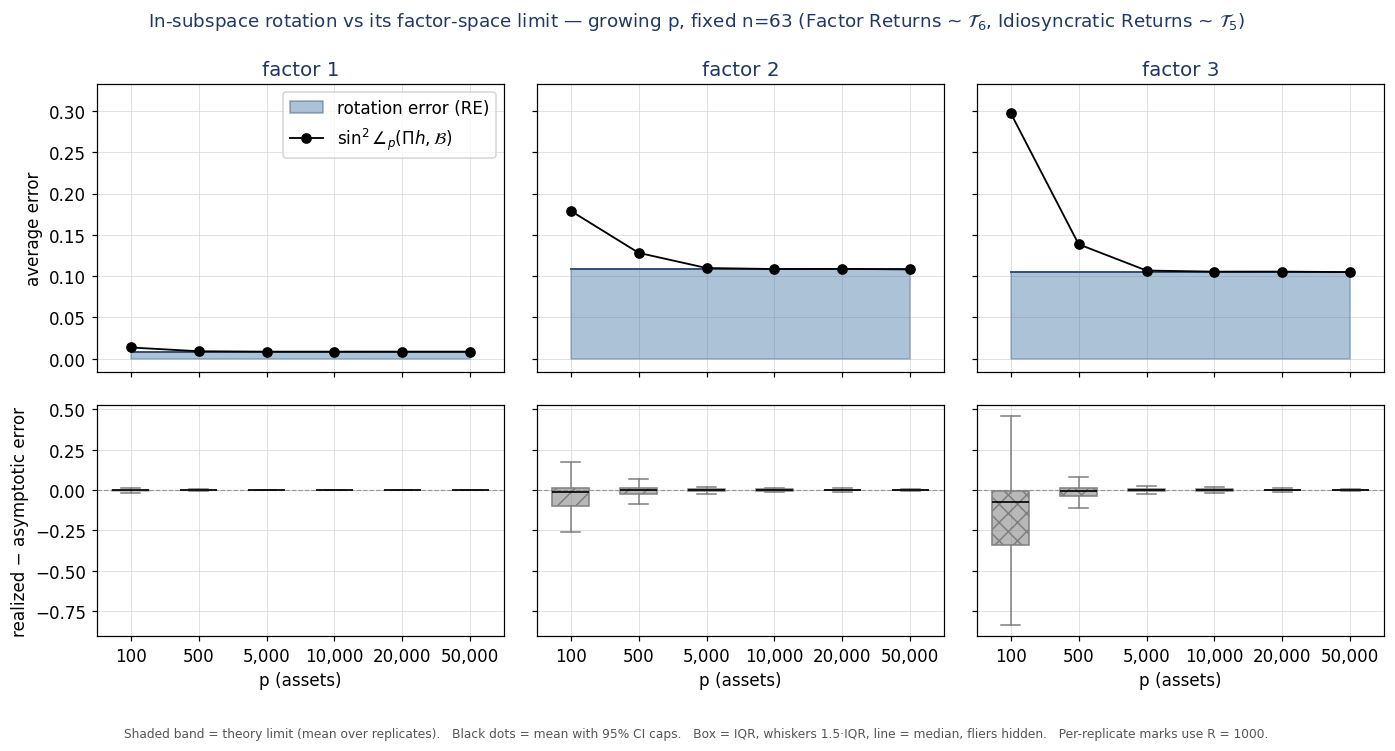

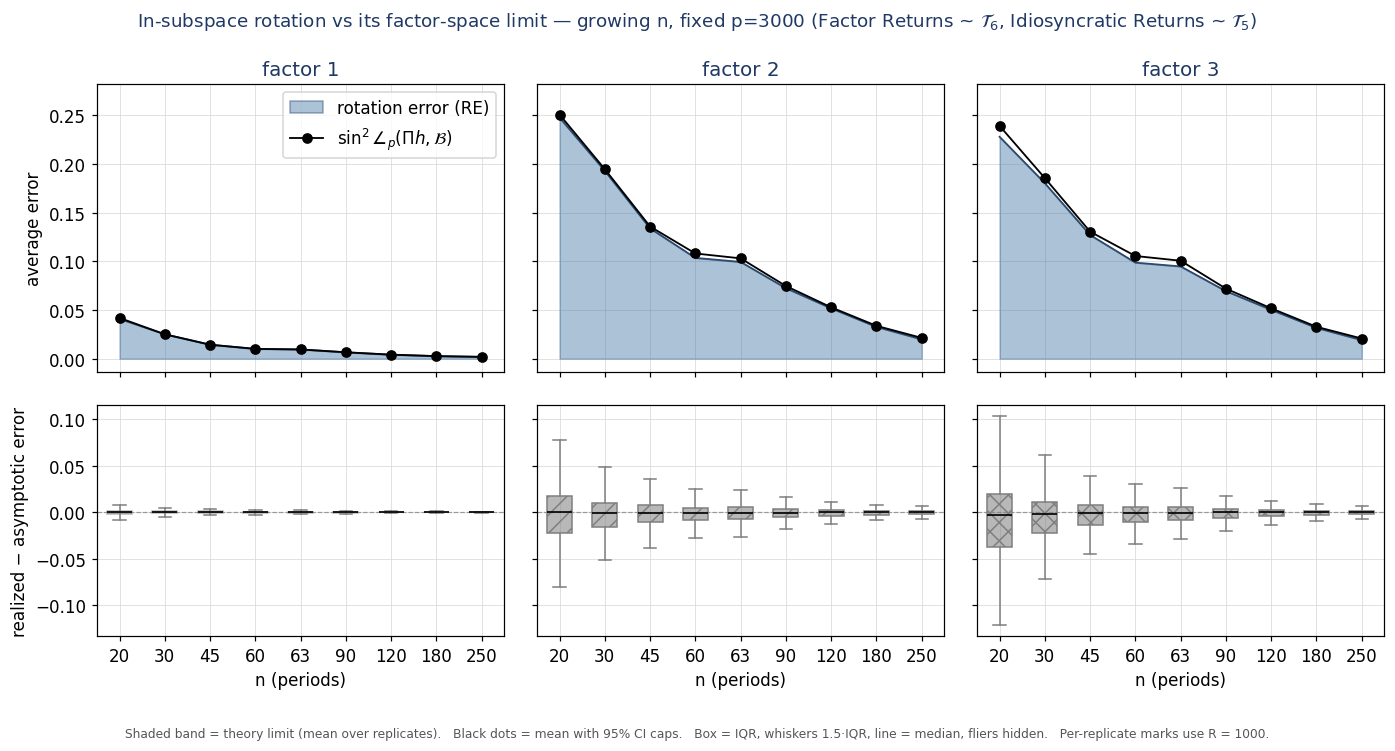

In [5]:
for df, key, lab in ((df_p, "p", "growing p, fixed n=63"),
                     (df_n, "n", "growing n, fixed p=3000")):
    fig, _ = grid(df, key,
                  rows=[Row([Band("rotation", label="rotation error (RE)"),
                             MeanCI("sin2_in", label=r"$\sin^2\angle_p(\Pi h,\mathcal{B})$")],
                            ylabel="average error", height=1.0),
                        Row(BoxDist("diff_in_rot"), ylabel="realized − asymptotic error")],
                  suptitle=f"In-subspace rotation vs its factor-space limit — {lab} {_TAILS}",
                  theme=MONO_THEME, formats=FIG_FORMATS, out_path=out(f"ex6_insub_vs_limit_{key}"))
    show(fig)

## Step 5 — the per-replicate distribution with the limit overlaid

Same data, distributional view: `BoxDist("sin2_in")` per swept value, with
`RefOverlay("rotation")` drawing the limit's median (dashed) and Q1–Q3 (translucent band)
on the same axis. One shared y across all panels (`sharey=True`, pinned to [0, 1]) so the
two sweeps are directly comparable.

**What to look for:** in the $p$-sweep the boxes descend onto a *flat* overlay — the limit
is a fixed-$n$ quantity that $p$ cannot improve; in the $n$-sweep both descend together.
The whiskers' upper tails for factors 2–3 are the identification-failure mass: at $n=63$
about 5% of replicates sit above 0.5 (the projected estimate more than 45° from its own
factor), and no amount of $p$ removes them.


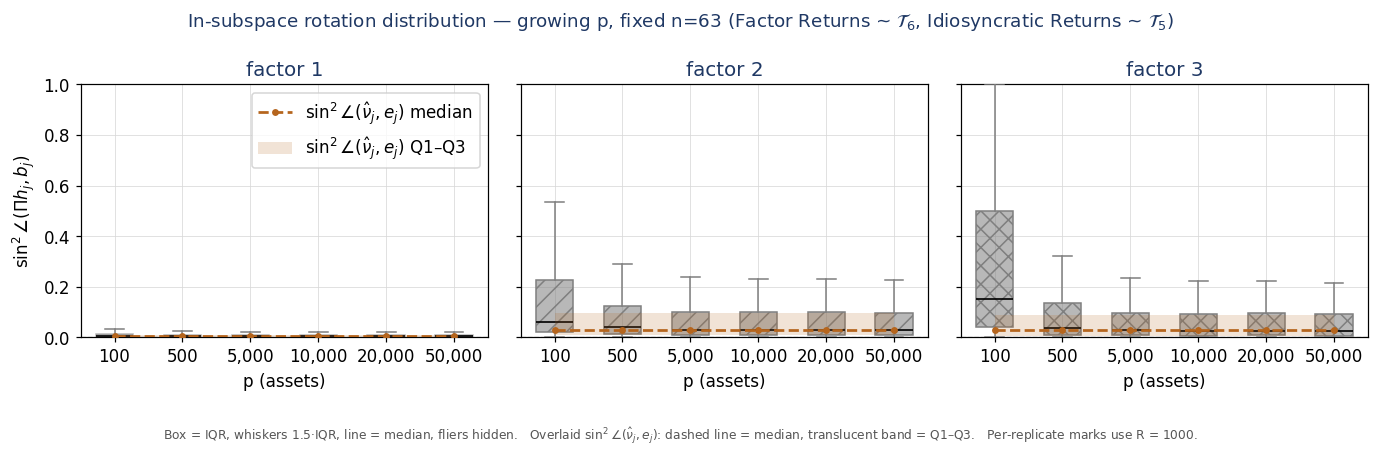

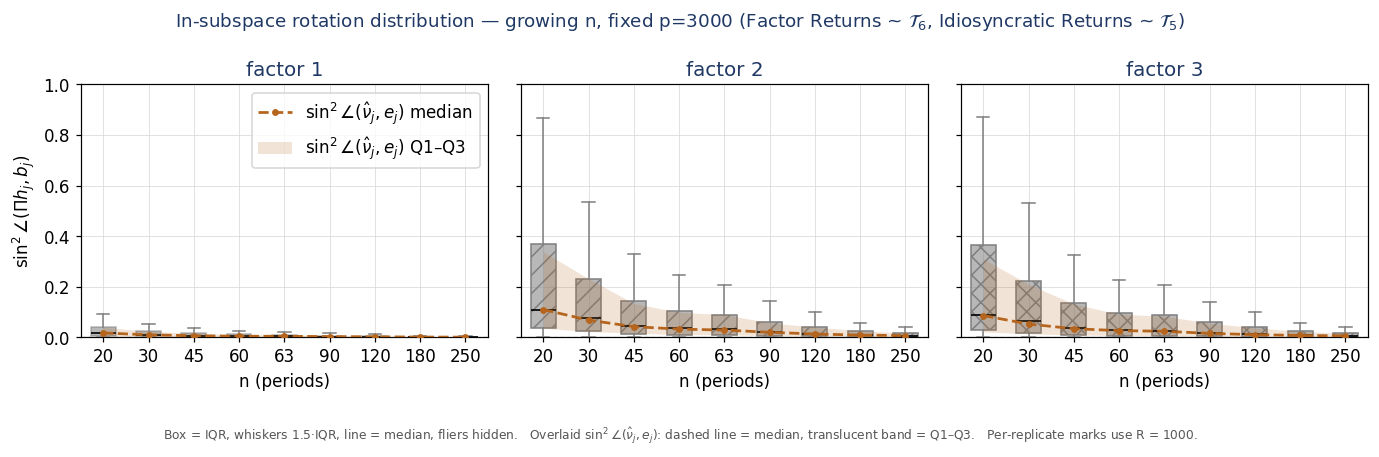

In [6]:
for df, key, lab in ((df_p, "p", "growing p, fixed n=63"),
                     (df_n, "n", "growing n, fixed p=3000")):
    fig, _ = grid(df, key,
                  rows=[Row([BoxDist("sin2_in"),
                             RefOverlay("rotation", label=r"$\sin^2\angle(\hat\nu_j, e_j)$")],
                            ylabel=r"$\sin^2\angle(\Pi h_j, b_j)$", ylim=(0, 1), height=1.0)],
                  sharey=True,
                  suptitle=f"In-subspace rotation distribution — {lab} {_TAILS}",
                  theme=MONO_THEME, formats=FIG_FORMATS, out_path=out(f"ex6_insub_dist_{key}"))
    show(fig)

## Step 6 — the disk views: rotation as a distribution over directions

Everything so far reduced each replicate to a scalar. The disks keep the **direction**:
each panel is the KDE cloud of $\Pi h_j/\lVert\Pi h_j\rVert$, plotted by its
$(b_2, b_3)$ coordinates (`DiskDensity` ignores the swept x-axis; each `Row` slices one
sweep value via `at={...}`, so a stack of rows walks the sweep while columns stay factors).

How to read a disk:

* **factor 1 (blue)** — its mass lives on $b_1$, which this plane doesn't show, so a
  well-estimated $h_1$ is a tight cloud at the **origin**;
* **factors 2–3 (orange/green)** — a well-estimated direction is a tight cloud **at its own
  axis on the boundary** (unit-normalized, so in-plane mass sits at radius ≈ 1);
* **the failure mode is an arc**, not a detached blob: in-plane rotation preserves unit
  norm, so misidentified replicates slide *along* the boundary from their own axis toward
  the other — the 2↔3 swap is the far end of a visible continuum.

**Figure 5** (growing $p$, $n=63$) adds a fourth row: the $\hat\nu_j$ cloud in the
$(e_2, e_3)$ plane — the $p\to\infty$ limit for the *same* replicates (nested design, same
realized $F$). The finite-$p$ clouds converge onto it: by $p=50{,}000$ the two rows should
be nearly indistinguishable, which is the theorem's convergence stated as pictures.
**Figure 6** (growing $n$, $p=3000$) shows the arc evaporating as $n$ resolves the
$\rho_2/\rho_3$ spike gap.


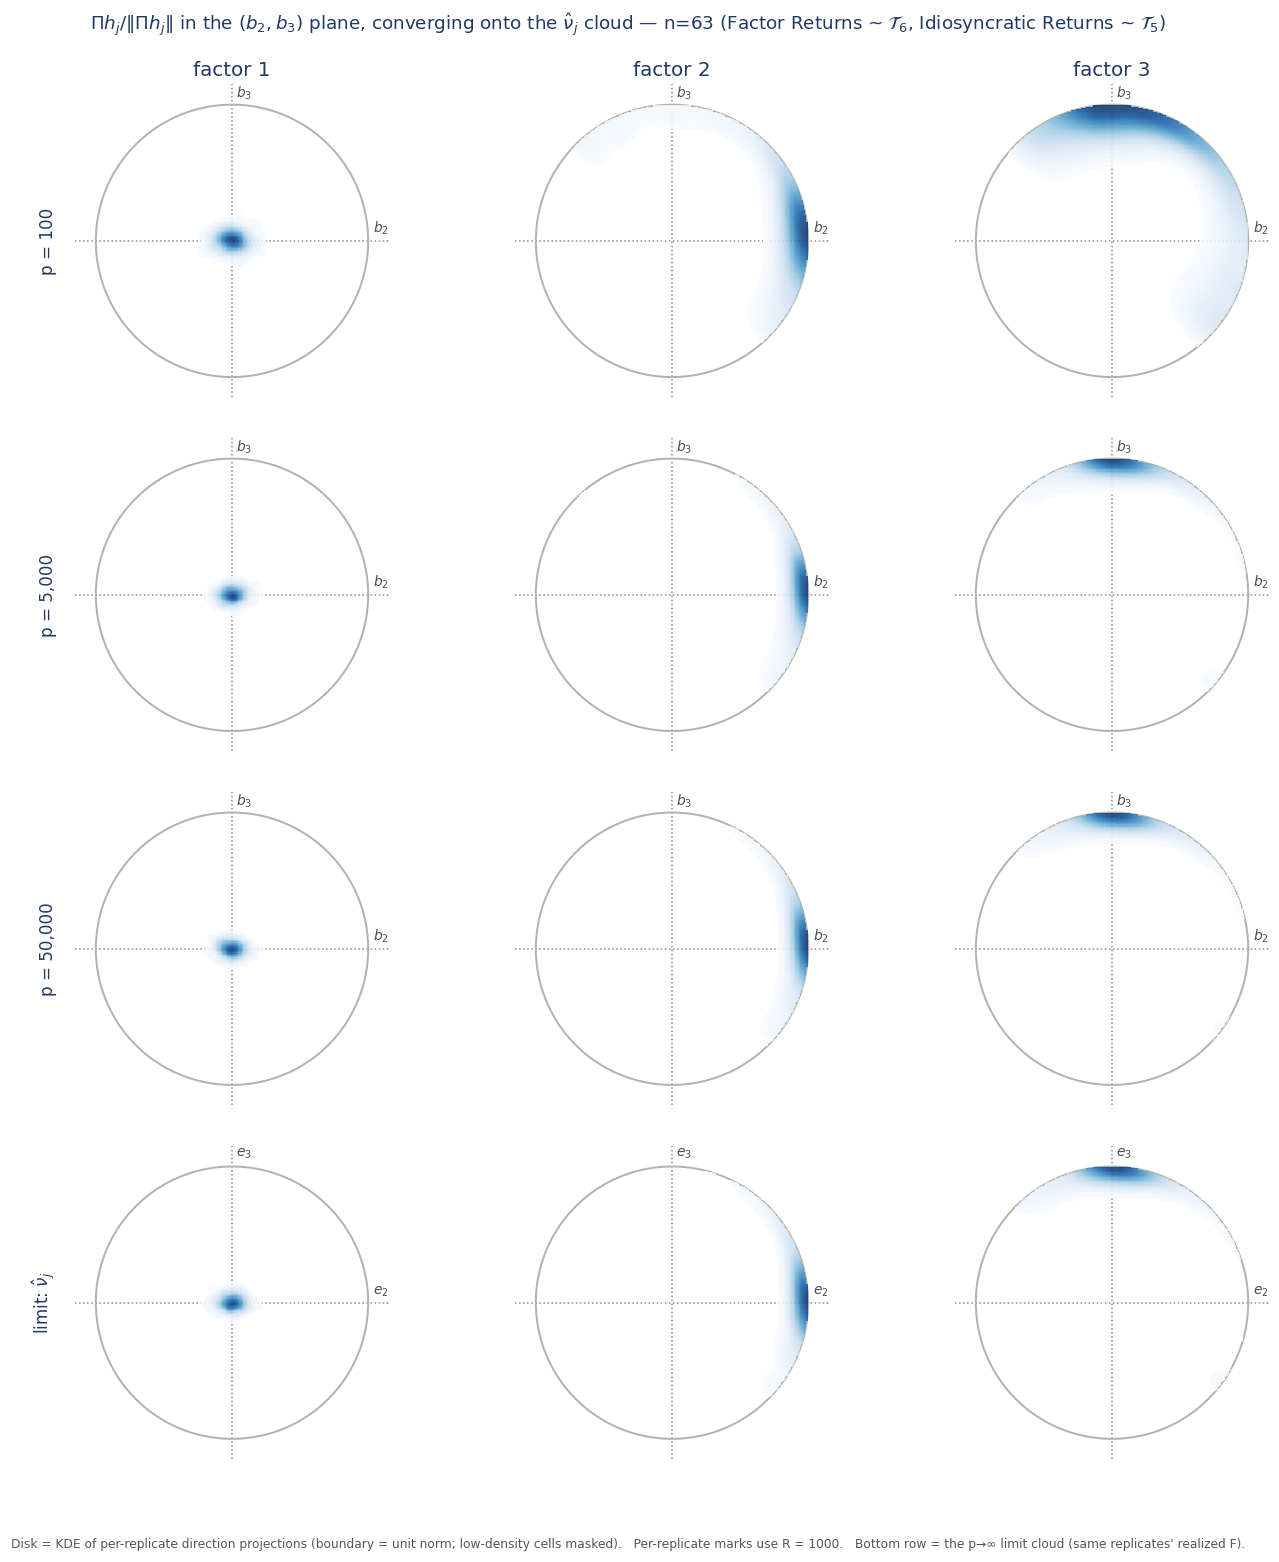

In [7]:
fig, _ = grid(df_p, "p",
              rows=[Row(DiskDensity("hd2", "hd3", at={"p": v}, labels=(r"$b_2$", r"$b_3$")),
                        ylabel=f"p = {v:,}", height=1.0) for v in (100, 5000, 50000)]
                   + [Row(DiskDensity("nud2", "nud3", at={"p": 50000},
                                      labels=(r"$e_2$", r"$e_3$")),
                          ylabel=r"limit: $\hat\nu_j$", height=1.0)],
              sharey=False,
              suptitle=rf"$\Pi h_j/\Vert\Pi h_j\Vert$ in the $(b_2, b_3)$ plane, "
                       rf"converging onto the $\hat\nu_j$ cloud — n=63 {_TAILS}",
              caption_extra="Bottom row = the p→∞ limit cloud (same replicates' realized F).",
              theme=MONO_THEME, formats=FIG_FORMATS, out_path=out("ex6_disks_growing_p"))
show(fig)

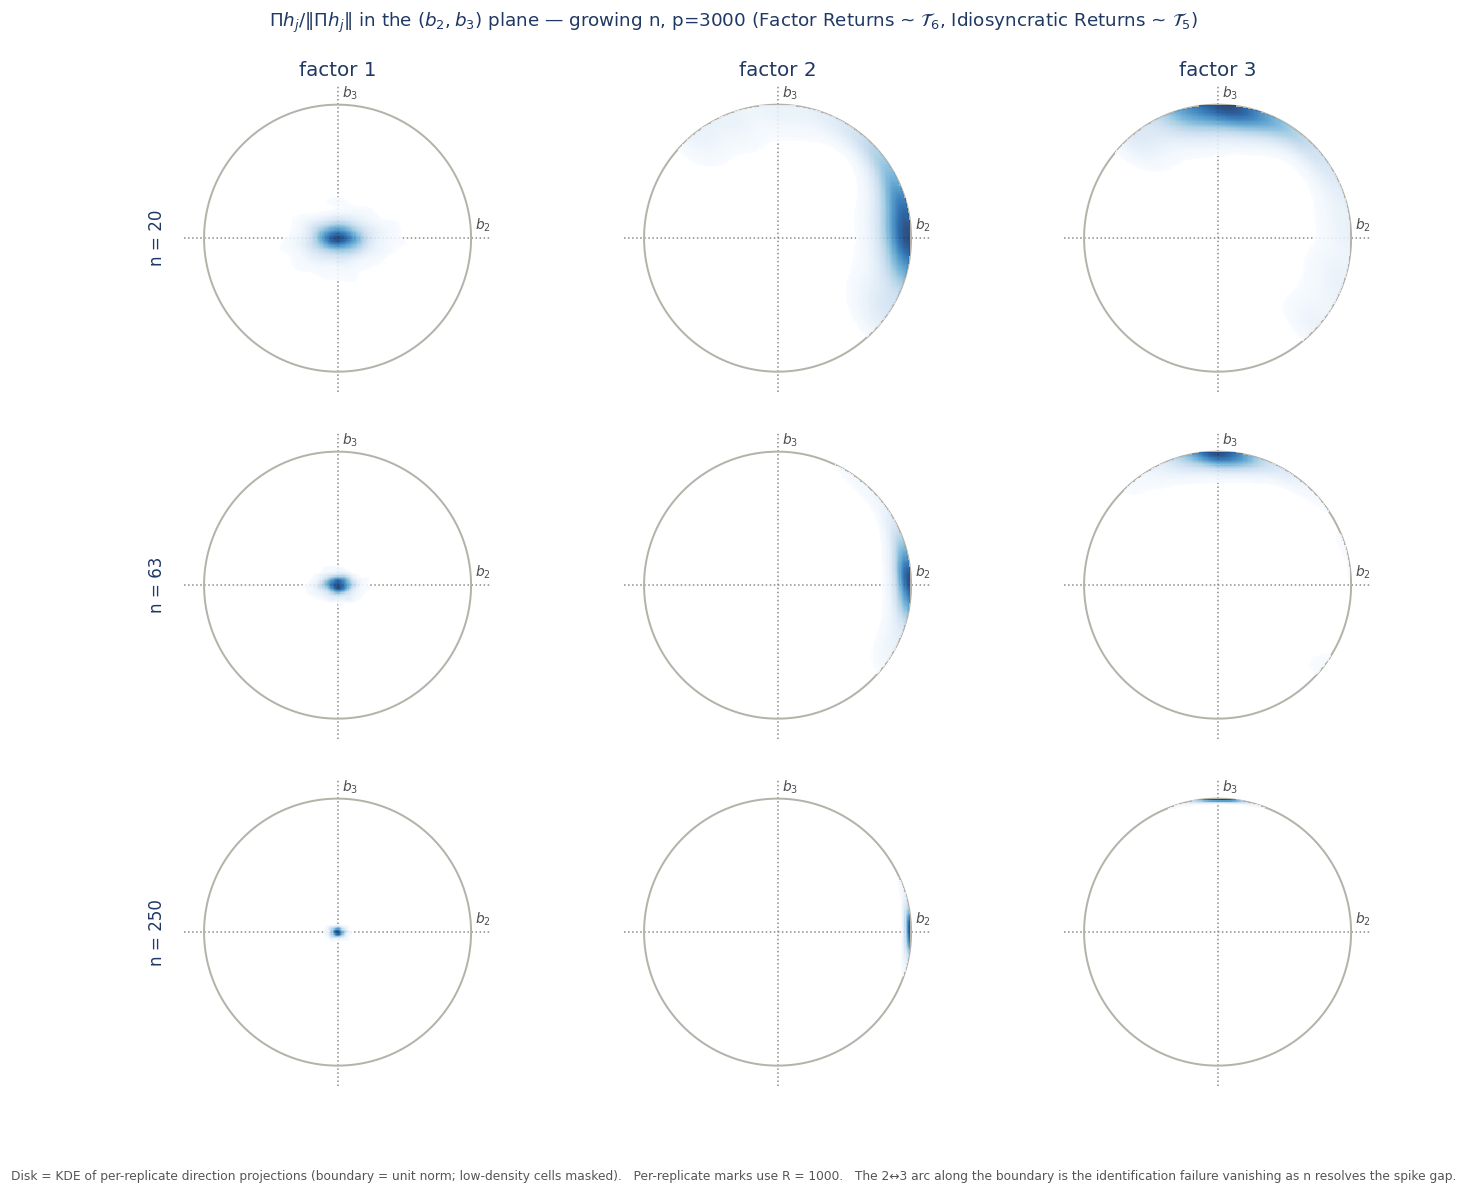

In [8]:
fig, _ = grid(df_n, "n",
              rows=[Row(DiskDensity("hd2", "hd3", at={"n": v}, labels=(r"$b_2$", r"$b_3$")),
                        ylabel=f"n = {v}", height=1.0) for v in (20, 63, 250)],
              sharey=False,
              suptitle=rf"$\Pi h_j/\Vert\Pi h_j\Vert$ in the $(b_2, b_3)$ plane — "
                       rf"growing n, p=3000 {_TAILS}",
              caption_extra="The 2↔3 arc along the boundary is the identification failure "
                            "vanishing as n resolves the spike gap.",
              theme=MONO_THEME, formats=FIG_FORMATS, out_path=out("ex6_disks_growing_n"))
show(fig)

## Step 6c — each estimated factor against *all* planes, and the share matrix

The transposed view (as in ex-7's Step 5b): **rows = estimated factors** $h_j$,
**columns = the successive planes** $(b_1, b_2)$ and $(b_2, b_3)$ — each row traces one
estimated direction through every 2-D window of the population frame. A healthy factor is
a tight boundary cloud at its own axis in the planes containing $b_j$ and an origin cloud
elsewhere; boundary mass anywhere else is leakage, localized to the window where it
appears.

Below it, the 3×3 **mean in-subspace mass-share matrix** (mean of
$\mathrm{hb}_i^2/\lVert\Pi h_j\rVert^2$; columns = estimated factors, sum to 100%) — the
confusion matrix for factor identification. Expect near-diagonal with one off-diagonal
block: the 2↔3 pair trading mass, shrinking as $n$ grows.


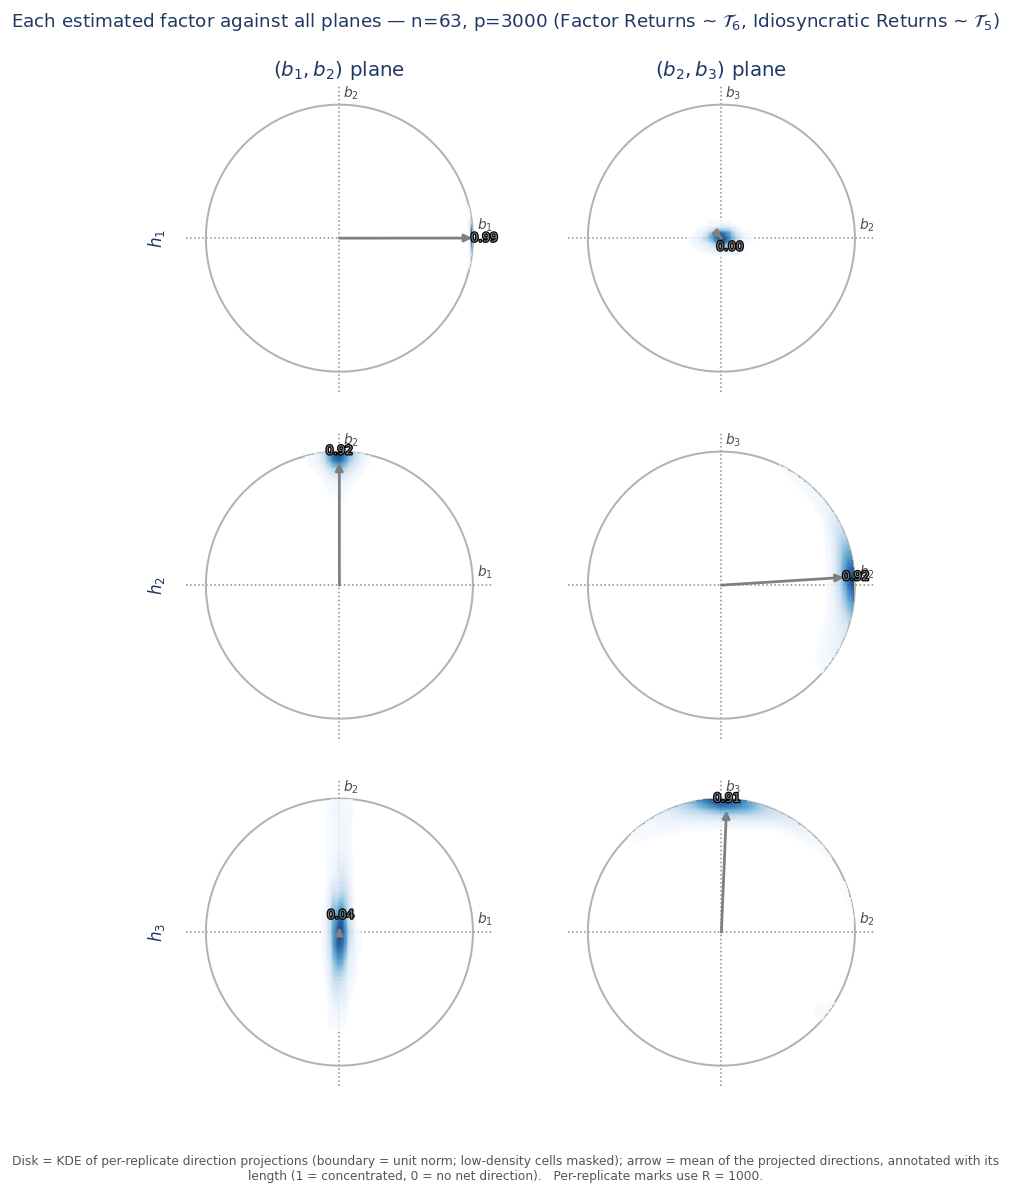

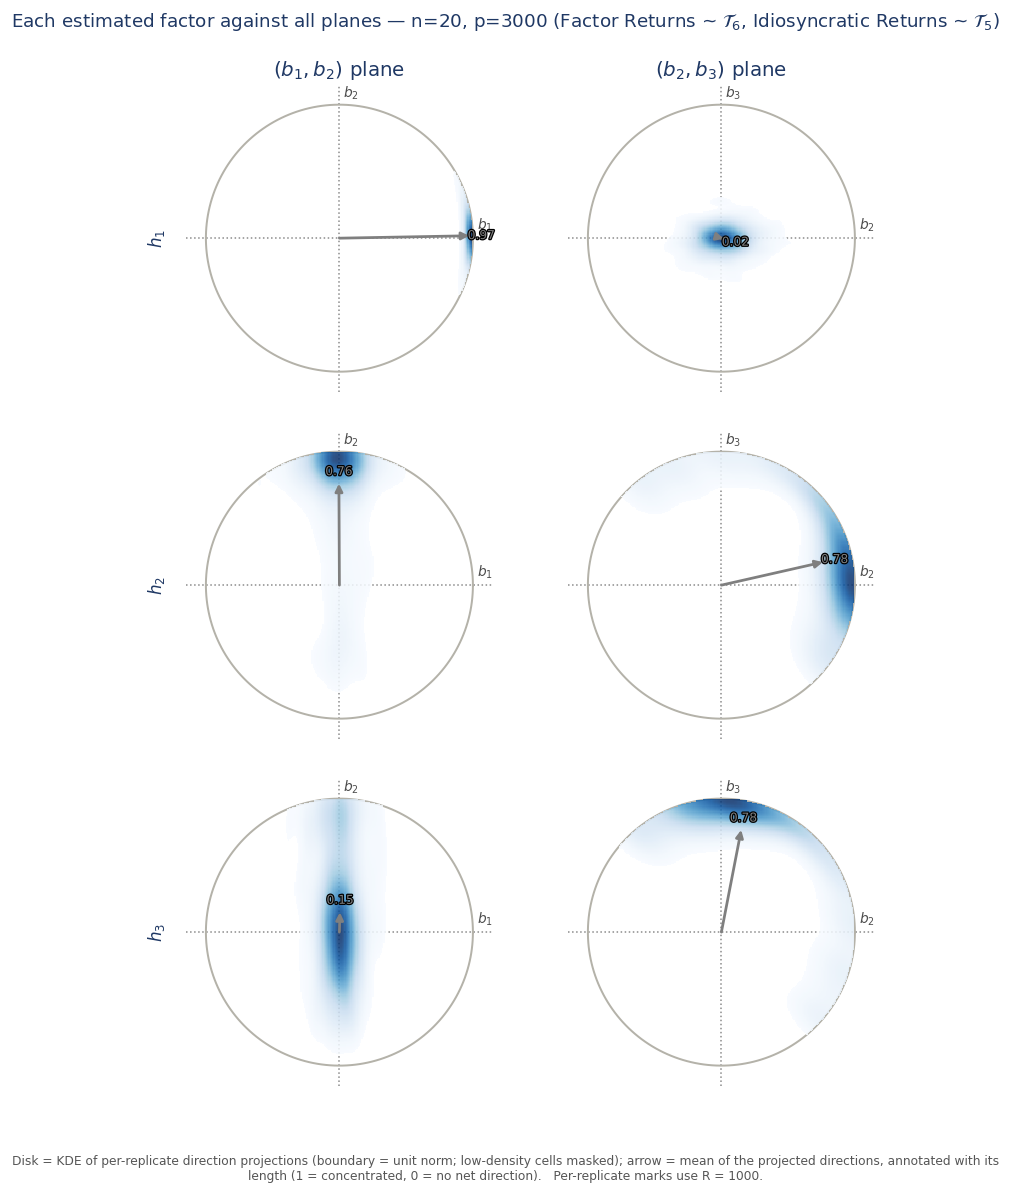

mean in-subspace mass share (%), n=20:


,h1,h2,h3
b1,95.8,3.1,1.4
b2,3.2,74.9,22.5
b3,1.0,22.0,76.1


mean in-subspace mass share (%), n=63:


,h1,h2,h3
b1,99.1,0.7,0.3
b2,0.7,89.7,9.8
b3,0.2,9.6,89.9


mean in-subspace mass share (%), n=250:


,h1,h2,h3
b1,99.8,0.1,0.1
b2,0.1,97.9,2.0
b3,0.1,2.0,97.9


In [9]:
_K = 3
_HB = [f"hb{i}" for i in range(1, _K + 1)]
_PAIRS3 = [(1, 2), (2, 3)]


def factor_vs_all(df, at, at_label, out_stem):
    """3×2 grid: rows = estimated factors h_j, columns = successive (b_i, b_{i+1}) planes."""
    fig, _ = grid(
        df, list(at.keys())[0], factors=[1, 2],          # 2 layout columns
        col_titles=[rf"$(b_{i}, b_{i + 1})$ plane" for i, _ in _PAIRS3],
        rows=[Row(cells=[[DiskDensity(f"hd{i}", f"hd{i + 1}", factor=j, at=at,
                                      mean_arrow=True,
                                      labels=(rf"$b_{i}$", rf"$b_{i + 1}$"))]
                         for i, _ in _PAIRS3],
                  ylabel=rf"$h_{j}$", height=1.0)
              for j in range(1, _K + 1)],
        sharey=False, figsize=(7.6, 11.0), legend_row=None,
        suptitle=rf"Each estimated factor against all planes — {at_label} {_TAILS}",
        theme=MONO_THEME, formats=FIG_FORMATS, out_path=out(out_stem))
    show(fig)


factor_vs_all(df_n, {"n": 63}, "n=63, p=3000", "ex6_factor_vs_all_n63")
factor_vs_all(df_n, {"n": 20}, "n=20, p=3000", "ex6_factor_vs_all_n20")


def share_matrix(df, at):
    """Mean in-subspace mass share: rows = population b_i, cols = estimated h_j (% sums to 100)."""
    s = df
    for c, v in at.items():
        s = s[s[c] == v]
    C2 = s[_HB].to_numpy() ** 2
    C2 = C2 / C2.sum(axis=1, keepdims=True)
    return pd.DataFrame(
        {f"h{j}": 100 * C2[s["j"].to_numpy() == j].mean(axis=0) for j in range(1, _K + 1)},
        index=[f"b{i}" for i in range(1, _K + 1)]).round(1)


for v in (20, 63, 250):
    print(f"mean in-subspace mass share (%), n={v}:")
    display(share_matrix(df_n, {"n": v}))


## Step 7 — the numbers behind the pictures

Per (swept value, factor): median / Q3 / p95 of the in-subspace rotation, and
`frac_gt_half` = the fraction of replicates beyond 45° — the scalar shadow of the arc in
the disks. Read the p-sweep rows to confirm the plateau (medians stop moving after
$p\approx5000$) and the n-sweep rows to confirm the tail is what decays
(`frac_gt_half` → 0 while medians were small all along).


In [10]:
def tail_table(df, key):
    return (df.groupby([key, "j"])["sin2_in"]
              .agg(median="median", q3=lambda s: s.quantile(0.75),
                   p95=lambda s: s.quantile(0.95),
                   frac_gt_half=lambda s: (s > 0.5).mean())
              .round(4))

print("growing p (n=63):")
display(tail_table(df_p, "p"))
print("growing n (p=3000):")
display(tail_table(df_n, "n"))

growing p (n=63):


median      q3     p95  frac_gt_half
p     j                                      
100   1  0.0071  0.0155  0.0427         0.001
      2  0.0613  0.2259  0.8557         0.115
      3  0.1504  0.4993  0.9639         0.250
500   1  0.0051  0.0110  0.0293         0.000
      2  0.0395  0.1246  0.7160         0.070
      3  0.0382  0.1353  0.7702         0.081
5000  1  0.0047  0.0101  0.0267         0.000
      2  0.0310  0.1024  0.5486         0.059
      3  0.0280  0.0983  0.5460         0.059
10000 1  0.0046  0.0100  0.0262         0.000
      2  0.0308  0.0991  0.5366         0.053
      3  0.0267  0.0940  0.5364         0.055
20000 1  0.0046  0.0101  0.0263         0.000
      2  0.0303  0.0993  0.5352         0.056
      3  0.0270  0.0953  0.5402         0.057
50000 1  0.0046  0.0100  0.0267         0.000
      2  0.0308  0.0983  0.5226         0.055
      3  0.0273  0.0910  0.5230         0.055

growing n (p=3000):


median      q3     p95  frac_gt_half
n   j                                      
20  1  0.0178  0.0415  0.1522         0.007
    2  0.1079  0.3699  0.9376         0.190
    3  0.0901  0.3662  0.9380         0.187
30  1  0.0108  0.0236  0.0810         0.004
    2  0.0758  0.2293  0.8765         0.131
    3  0.0630  0.2240  0.8646         0.129
45  1  0.0068  0.0161  0.0431         0.001
    2  0.0456  0.1422  0.7307         0.074
    3  0.0365  0.1372  0.7218         0.077
60  1  0.0048  0.0116  0.0291         0.001
    2  0.0356  0.1058  0.5629         0.056
    3  0.0286  0.0966  0.5718         0.057
63  1  0.0047  0.0106  0.0284         0.001
    2  0.0320  0.0902  0.5351         0.055
    3  0.0264  0.0870  0.5521         0.055
90  1  0.0034  0.0074  0.0187         0.001
    2  0.0210  0.0622  0.3352         0.034
    3  0.0174  0.0605  0.3351         0.033
120 1  0.0026  0.0054  0.0126         0.000
    2  0.0144  0.0424  0.2261         0.020
    3  0.0121  0.0421  0.2290         0.020
180 1  0.0015  0.0034  0.0084         0.000
    2  0.0099  0.0257  0.1198         0.008
    3  0.0085  0.0243  0.1214         0.008
250 1  0.0011  0.0025  0.0064         0.000
    2  0.0075  0.0186  0.0686         0.004
    3  0.0064  0.0176  0.0668         0.004

---
## Component-colored versions

Quantity palette instead of factor colors: the measured object throughout this notebook
is the **in-subspace** rotation of $h_j$, so its boxes/dots/clouds take the in-subspace
orange (`#f28e2b`); the $k\times k$ **rotation** limit takes green. Matches the band-fill
convention of the ex-2/ex-3 figures.

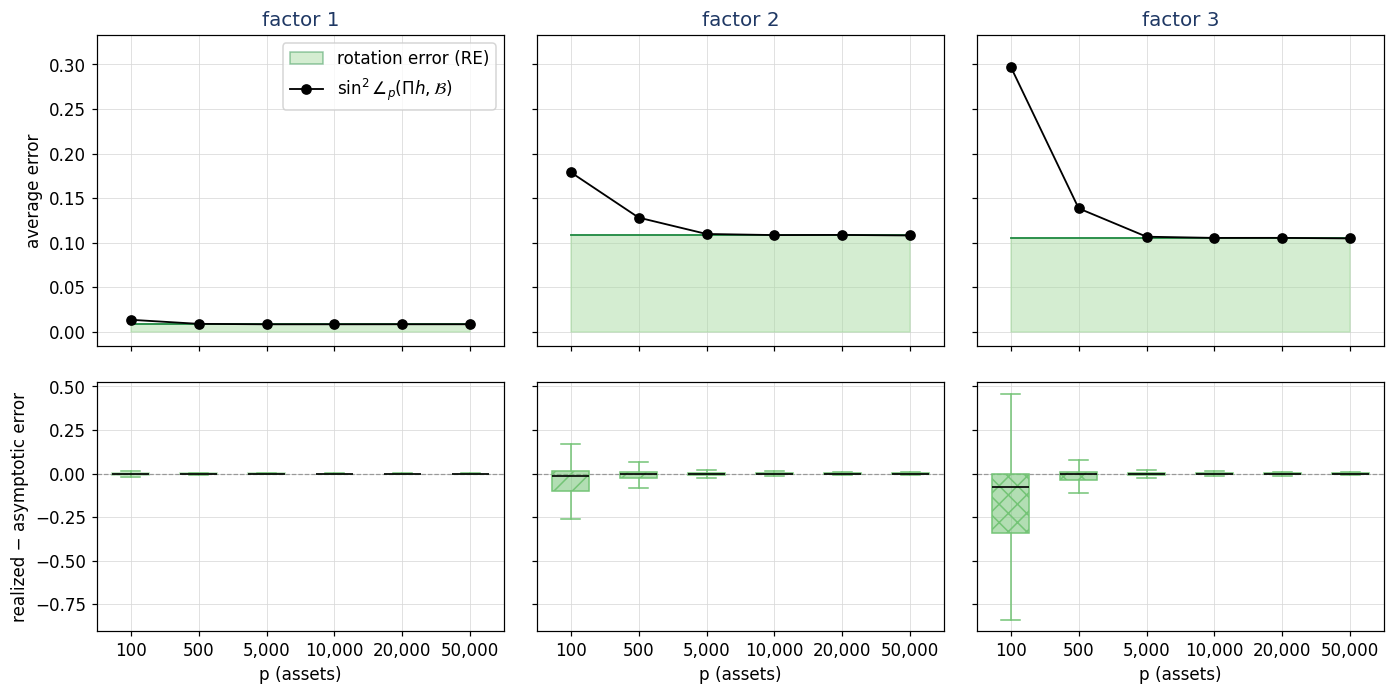

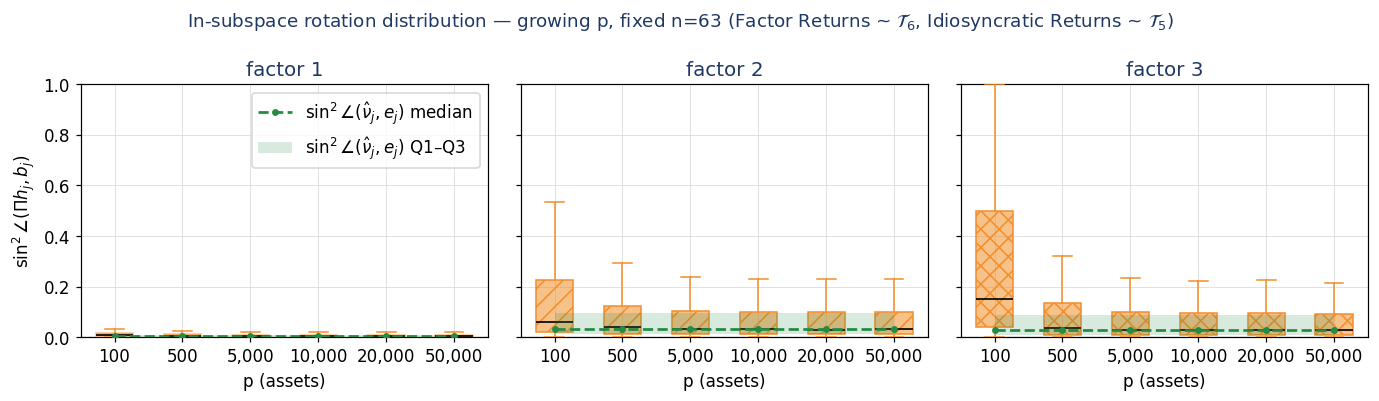

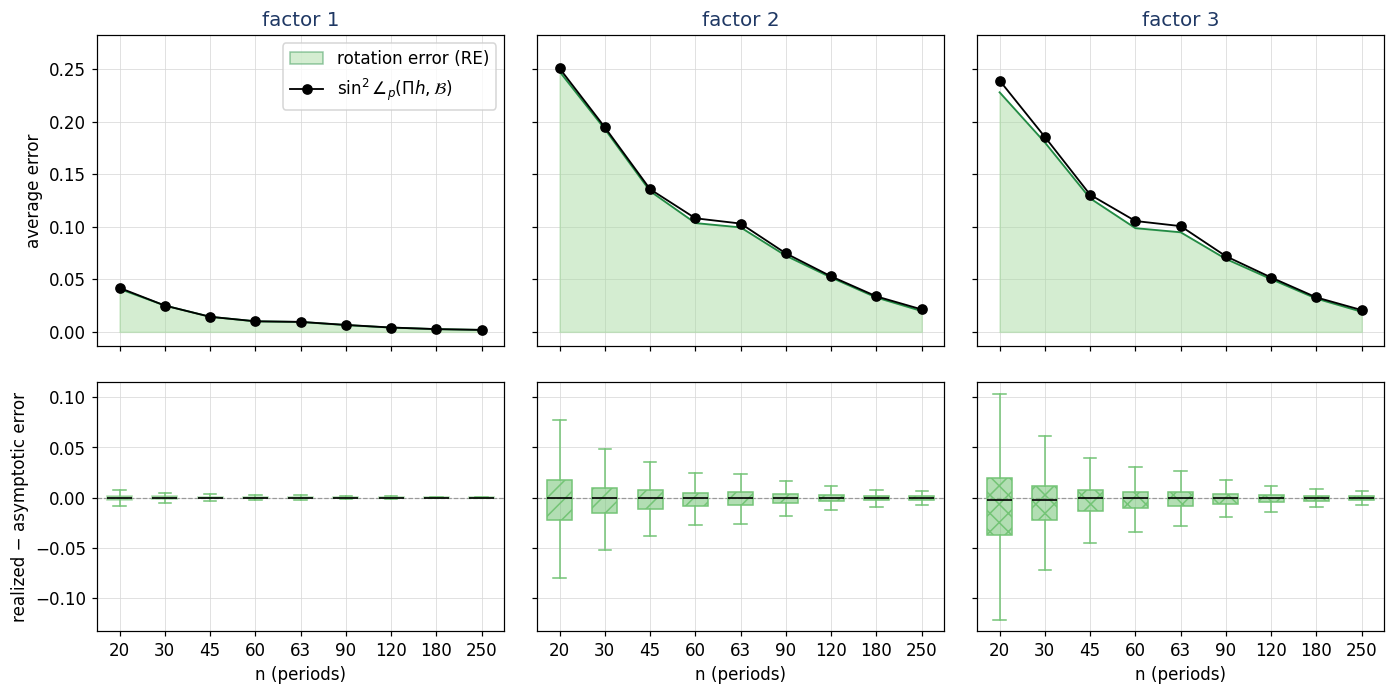

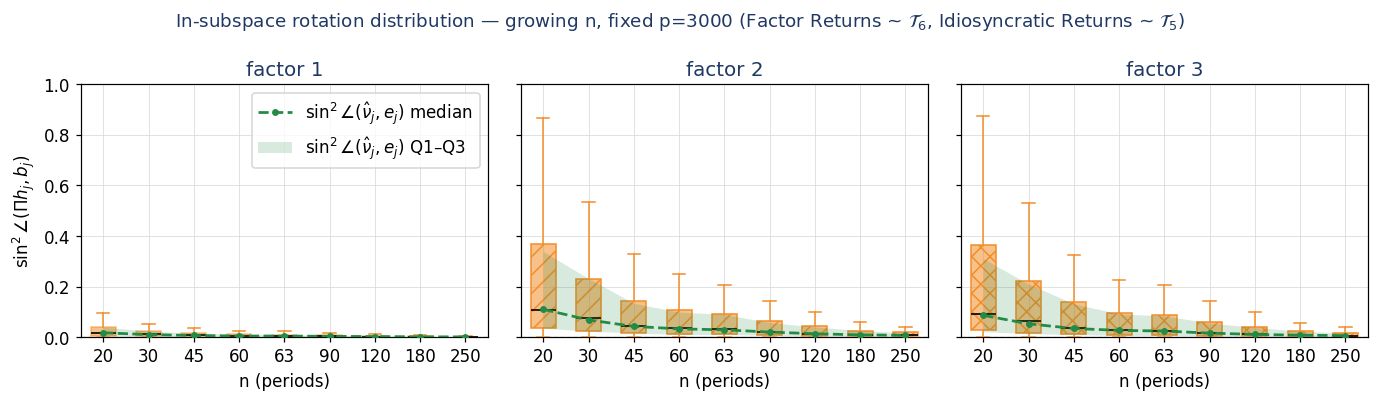

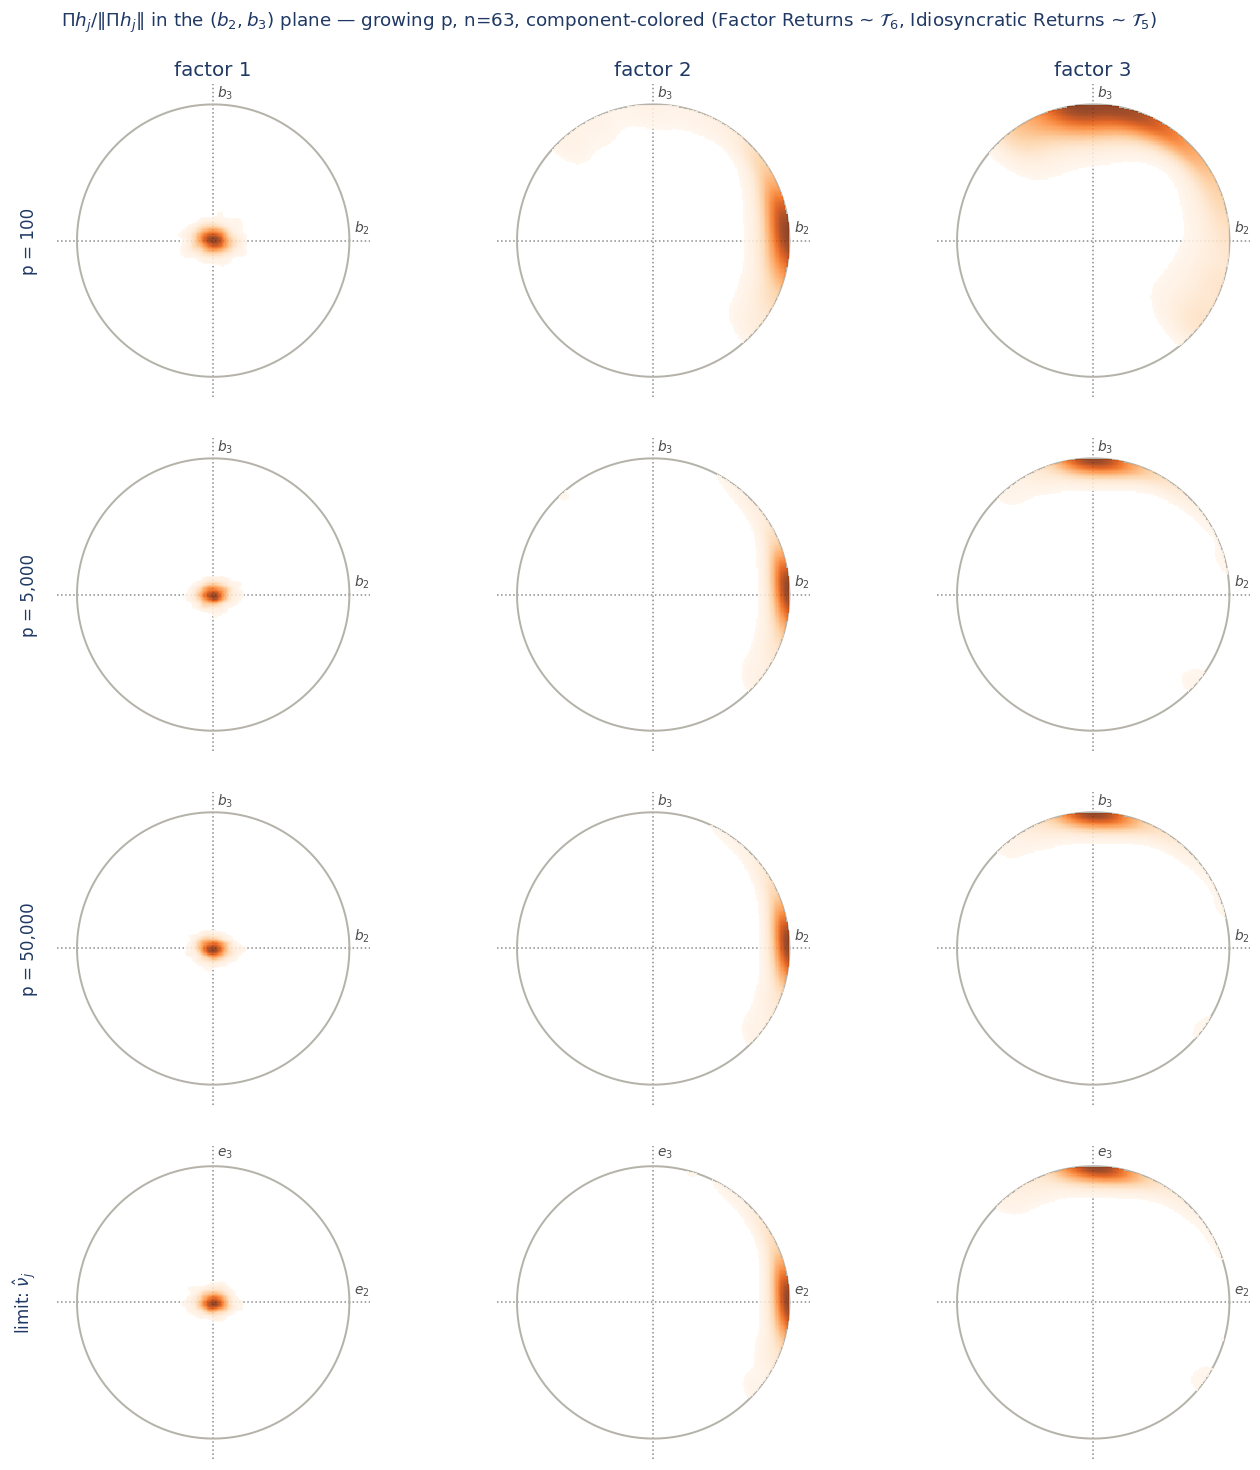

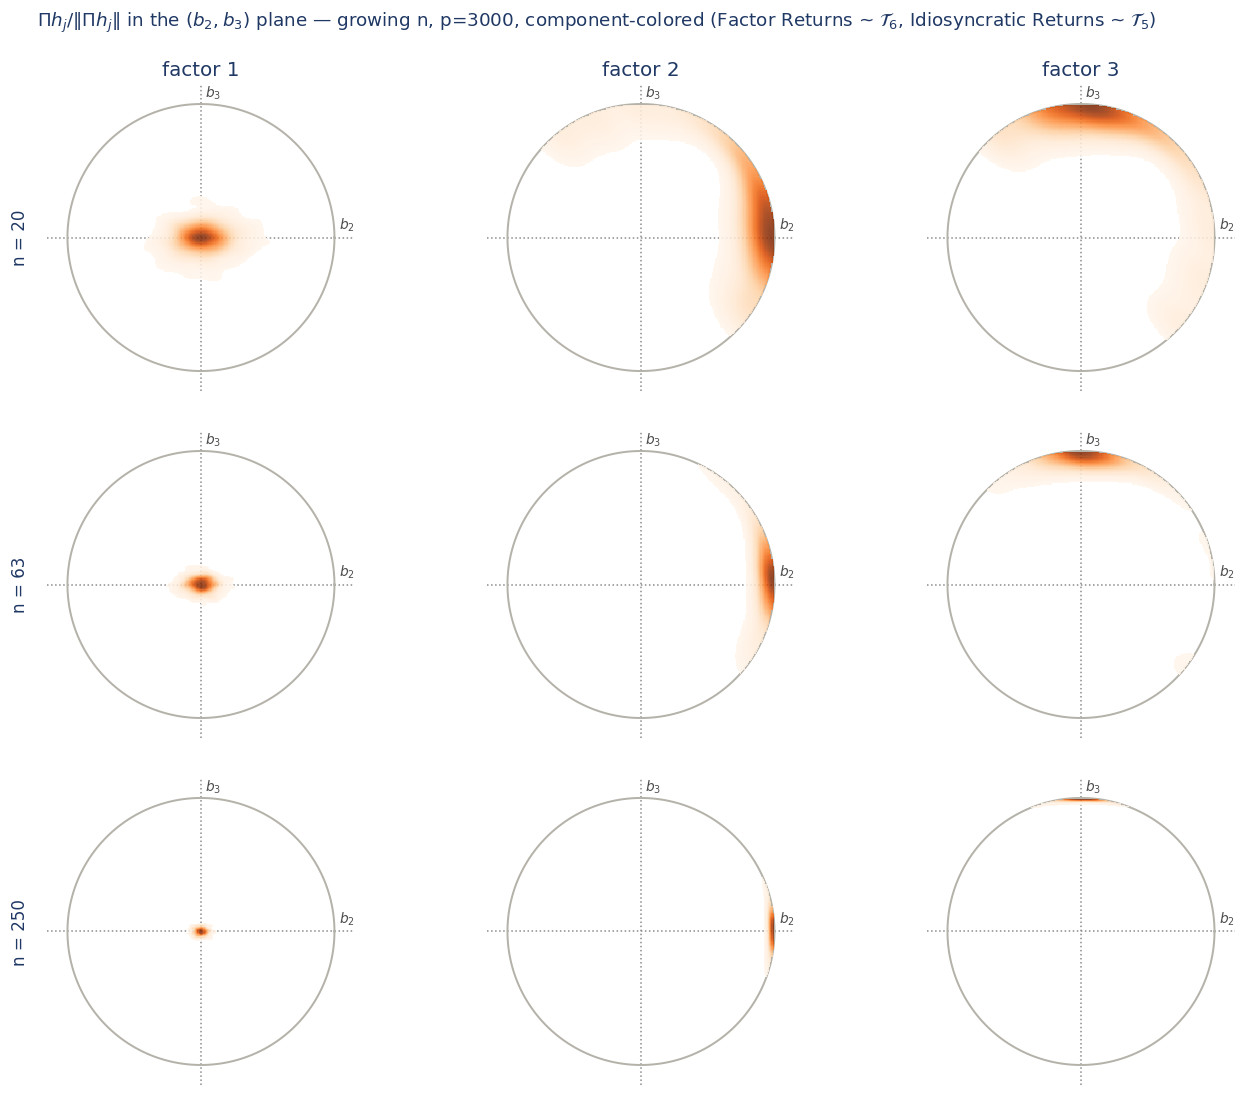

In [11]:
COMP_INSUB_THEME = Theme(factor_colors=("#f28e2b",) * 6, factor_cmaps=("Oranges",) * 6,
                         factor_hatches=FACTOR_HATCHES,
                         ci_caps=dict(fmt="none", ecolor="black", elinewidth=0.0, capsize=0))
COMP_ROT_FILL, COMP_ROT_LINE = "#a1d99b", "#238b45"
def comp_theme(color, cmap="Blues"):
    return Theme(factor_colors=(color,) * 6, factor_cmaps=(cmap,) * 6,
                 factor_hatches=FACTOR_HATCHES,
                 ci_caps=dict(fmt="none", ecolor="black", elinewidth=0.0, capsize=0))
ROT_T = comp_theme("#74c476", "Greens")

for df, key, lab in ((df_p, "p", "growing p, fixed n=63"),
                     (df_n, "n", "growing n, fixed p=3000")):
    # measured (orange) vs its rotation limit (green band)
    fig, _ = grid(df, key,
                  rows=[Row([Band("rotation", label="rotation error (RE)",
                                  fill=COMP_ROT_FILL, line=COMP_ROT_LINE),
                             MeanCI("sin2_in", label=r"$\sin^2\angle_p(\Pi h,\mathcal{B})$")],
                            ylabel="average error", height=1.0),
                        Row(BoxDist("diff_in_rot"), ylabel="realized − asymptotic error")],
                  # theme=COMP_INSUB_THEME,
                  theme=ROT_T,
                #   suptitle=f"In-subspace rotation vs its factor-space limit — {lab} {_TAILS}",
                  formats=FIG_FORMATS, out_path=out(f"ex6_insub_vs_limit_{key}_qcolor", save=True),
                  caption=False)
    show(fig)
    # distribution (orange boxes) with the rotation limit overlaid (green)
    fig, _ = grid(df, key,
                  rows=[Row([BoxDist("sin2_in"),
                             RefOverlay("rotation", label=r"$\sin^2\angle(\hat\nu_j, e_j)$",
                                        color=COMP_ROT_LINE)],
                            ylabel=r"$\sin^2\angle(\Pi h_j, b_j)$", ylim=(0, 1), height=1.0)],
                  sharey=True, theme=COMP_INSUB_THEME,
                  suptitle=f"In-subspace rotation distribution — {lab} {_TAILS}",
                  formats=FIG_FORMATS, out_path=out(f"ex6_insub_dist_{key}_qcolor"),
                  caption=False)
    show(fig)

# disk grids: the clouds are in-subspace directions -> Oranges
fig, _ = grid(df_p, "p",
              rows=[Row(DiskDensity("hd2", "hd3", at={"p": v}, labels=(r"$b_2$", r"$b_3$")),
                        ylabel=f"p = {v:,}", height=1.0) for v in (100, 5000, 50000)]
                   + [Row(DiskDensity("nud2", "nud3", at={"p": 50000},
                                      labels=(r"$e_2$", r"$e_3$")),
                          ylabel=r"limit: $\hat\nu_j$", height=1.0)],
              sharey=False, theme=COMP_INSUB_THEME, suptitle=rf"$\Pi h_j/\Vert\Pi h_j\Vert$ in the $(b_2, b_3)$ plane — "
                       rf"growing p, n=63, component-colored {_TAILS}",
              formats=FIG_FORMATS, out_path=out("ex6_disks_growing_p_qcolor"),
              caption=False)
show(fig)
fig, _ = grid(df_n, "n",
              rows=[Row(DiskDensity("hd2", "hd3", at={"n": v}, labels=(r"$b_2$", r"$b_3$")),
                        ylabel=f"n = {v}", height=1.0) for v in (20, 63, 250)],
              sharey=False, theme=COMP_INSUB_THEME, suptitle=rf"$\Pi h_j/\Vert\Pi h_j\Vert$ in the $(b_2, b_3)$ plane — "
                       rf"growing n, p=3000, component-colored {_TAILS}",
              formats=FIG_FORMATS, out_path=out("ex6_disks_growing_n_qcolor"),
              caption=False)
show(fig)


---
## Change log

- **2026-08-01**: new notebook, structured as a step-by-step walkthrough — the ex-2 v2
  in-subspace rotation figures recomposed on `fl_plot` (its first real consumer), plus the
  disk-density direction clouds of $\Pi h_j/\lVert\Pi h_j\rVert$ and $\hat\nu_j$. Sweeps
  re-run once with `InSubRotationExperiment` to record the projection coordinates (`hb*`,
  `nu*`) the disks need; cached to `ex6_df_{p,n}.parquet` with a column-aware guard. Same
  model / designs / seed as ex-2 v2, so the scalar columns reproduce that notebook's
  numbers exactly; no `.py` experiment files touched. Figures →
  `nb_outputs/ex-6_insub_rotation/`.
- **2026-08-03**: Step 6b — factor-pair plane figures ($(b_1,b_2)$, $(b_2,b_3)$) with
  overlaid clouds and mean arrows (`DiskDensity(factor=..., mean_arrow=True)`); derive now
  emits all normalized coordinates (`hd1..3`, `nud1..3`).
- **2026-08-03 (b)**: Step 6c — the transposed view (rows = estimated factors, columns =
  all successive planes) at n=63 and n=20, plus 3×3 mean in-subspace mass-share matrices
  at n ∈ {20, 63, 250} (the identification confusion matrix; the 2↔3 block shrinks from
  22% to 2% as n grows).
- **2026-08-03 (c)**: Step 6d — the growing-p experiment as a single strip: all three
  clouds + arrows on one $(b_2, b_3)$ disk per panel, columns p = 100 / 5,000 / 50,000 →
  the $\hat\nu$ limit panel.

- **2026-08-04**: Step 6e — raw-cosine strip against $(b_1, b_2)$ (unnormalized, so the
  radial deficit shows all losses including the floor), with the parallelism check
  (disk arrows ≡ $\sqrt{1-\sin^2_j}$; true angles 17°/38°/46° at p=50,000). Caps removed
  from ex-2 v2's component top rows the same day (separate notebook). An ℓ-frame
  (pre-orthogonalization loadings) variant was explored and dropped as redundant; its
  `lb*`/`frame*` columns remain recorded in the parquet cache.

- **mono duplicate**: single color for all per-factor marks, no CI caps on measured dots, overlay disk figures omitted.
